# PROJECT-3. EDA + Feature Engineering. Соревнование на Kaggle

Итоговый проект блока EDA, Booking: предсказание `reviewer_score`

**Рубинштейн Андрей**, DSPR-192

Риелторы тут ни при чём. Задача: по отзыву понять, какой рейтинг поставит гость. Если факт сильно уезжает от прогноза, отель можно проверить на накрутку

Train с Kaggle: `data/sf-booking/hotels_train.csv` (тот же объём, что LMS `hotels.csv`). Тест и образец сабмита лежат рядом


In [2]:
import re
from pathlib import Path

import category_encoders as ce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn import metrics

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

DATA_DIR = Path("data/sf-booking")
train_path = DATA_DIR / "hotels_train.csv"
if not train_path.exists():
    train_path = Path("data/hotels.csv")

hotels = pd.read_csv(train_path)
print(hotels.shape)
hotels.head(3)


(386803, 17)


## 1. Данные

Пропуски только в координатах. Строки pandas 2.x пишет как `str`, не `object`. Для модели оставлю числа, из строк сначала вытащу признаки


In [4]:
print(hotels.isna().sum()[hotels.isna().sum() > 0])
print()
print(hotels.dtypes)
print()
print("полных дублей строк:", int(hotels.duplicated().sum()))


lat    2448
lng    2448
dtype: int64

hotel_address                                     str
additional_number_of_scoring                    int64
review_date                                       str
average_score                                 float64
hotel_name                                        str
reviewer_nationality                              str
negative_review                                   str
review_total_negative_word_counts               int64
total_number_of_reviews                         int64
positive_review                                   str
review_total_positive_word_counts               int64
total_number_of_reviews_reviewer_has_given      int64
reviewer_score                                float64
tags                                              str
days_since_review                                 str
lat                                           float64
lng                                           float64
dtype: object

полных дублей строк: 307


Пропуски: `lat` и `lng`. Полных дублей строк тоже есть - сниму после базовой модели, чтобы сначала повторить MAPE из юнита 3


In [6]:
print("уникальных отелей:", hotels["hotel_name"].nunique())
hotels["review_date"] = pd.to_datetime(hotels["review_date"])
print("самый свежий отзыв:", hotels["review_date"].max().date())
print("самый первый отзыв:", hotels["review_date"].min().date())


уникальных отелей: 1492
самый свежий отзыв: 2017-08-03
самый первый отзыв: 2015-08-04


In [7]:
def parse_tags(value):
    return re.findall(r"' ([^']+?) '", str(value))


tag_series = hotels["tags"].map(parse_tags)
all_tags = tag_series.explode()
print("уникальных тегов:", all_tags.nunique())
print(all_tags.value_counts().head(5))

nights = all_tags.str.extract(r"Stayed (\d+) night")[0].dropna().astype(int)
print("ночей чаще всего:", int(nights.mode().iloc[0]))


уникальных тегов: 2368
tags
Leisure trip                      313593
Submitted from a mobile device    230778
Couple                            189212
Stayed 1 night                    145373
Stayed 2 nights                   100263
Name: count, dtype: int64
ночей чаще всего: 1


1492 отеля. Отзывы с 2015-08-04 по 2017-08-03. Уникальных тегов 2368, самый частый - Leisure trip. Чаще всего живут 1 ночь


cell_8:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


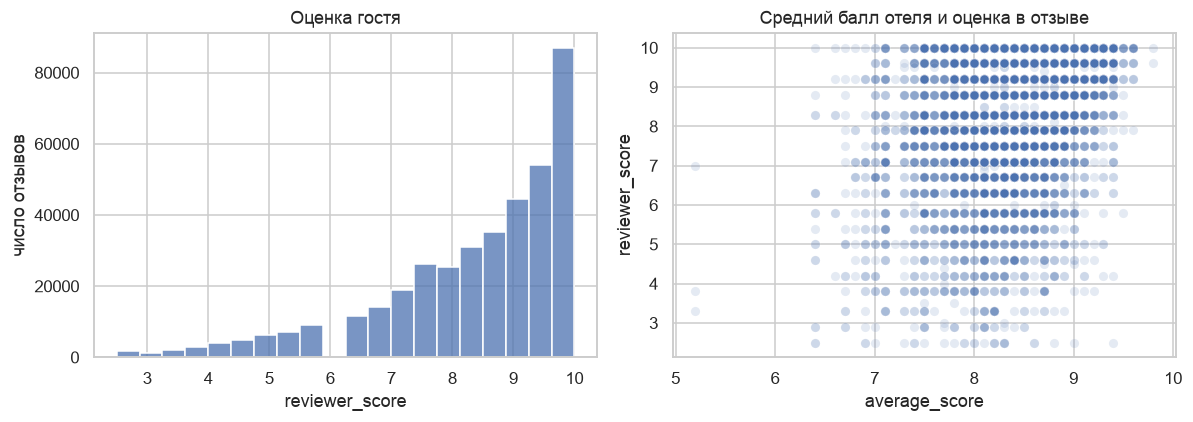

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(hotels["reviewer_score"], bins=20, ax=axes[0])
axes[0].set_title("Оценка гостя")
axes[0].set_xlabel("reviewer_score")
axes[0].set_ylabel("число отзывов")
sns.scatterplot(
    data=hotels.sample(8000, random_state=42),
    x="average_score",
    y="reviewer_score",
    alpha=0.15,
    ax=axes[1],
)
axes[1].set_title("Средний балл отеля и оценка в отзыве")
axes[1].set_xlabel("average_score")
axes[1].set_ylabel("reviewer_score")
plt.tight_layout()
plt.show()


Оценки прибиты к 8-10. Средний балл отеля связан с оценкой в отзыве, но разброс большой - одними звёздами отеля не обойтись. Дальше смотрю слова в негативе и теги


## 2. Базовая модель

Как в юните 3: выкидываю нечисловые столбцы, пропуски в координатах заполняю нулём. Так учиться плохо, но так просили получить первую MAPE


In [12]:
df_base = hotels.select_dtypes(include=[np.number]).copy()
df_base = df_base.fillna(0)

X = df_base.drop(["reviewer_score"], axis=1)
y = df_base["reviewer_score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

regr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)
print("MAPE:", metrics.mean_absolute_percentage_error(y_test, y_pred))


MAPE: 0.1413729386887362


MAPE около 0.141. Лес ругается, если в таблицу попадают строки: в свежем pandas адрес имеет тип `str`, не `object`. Поэтому для базы беру `select_dtypes(include=[np.number])`


## 2.1. Очистка: дубли и выбросы

Базу посчитал на сырых данных. Дальше по EDA-1: полные дубли строк и метод Тьюки по числу слов в отзыве. Строки с длинным текстом не удаляю - это живые отзывы, только клипую хвост


строк до очистки: 386803
полных дублей: 307
cell_14:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
верхняя граница Тьюки, негатив: 54.5
верхняя граница Тьюки, позитив: 47.5
строк после дублей: 386496


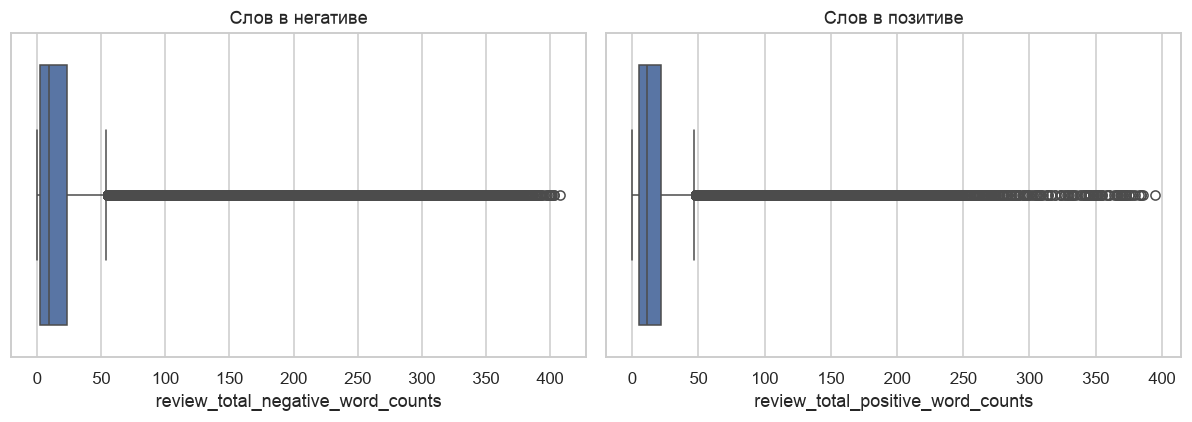

In [15]:
print("строк до очистки:", hotels.shape[0])
print("полных дублей:", int(hotels.duplicated().sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(
    x=hotels["review_total_negative_word_counts"], ax=axes[0], showfliers=True
)
axes[0].set_title("Слов в негативе")
axes[0].set_xlabel("review_total_negative_word_counts")
sns.boxplot(
    x=hotels["review_total_positive_word_counts"], ax=axes[1], showfliers=True
)
axes[1].set_title("Слов в позитиве")
axes[1].set_xlabel("review_total_positive_word_counts")
plt.tight_layout()
plt.show()


def tukey_upper(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return q3 + 1.5 * (q3 - q1)


neg_hi = tukey_upper(hotels["review_total_negative_word_counts"])
pos_hi = tukey_upper(hotels["review_total_positive_word_counts"])
print("верхняя граница Тьюки, негатив:", round(neg_hi, 1))
print("верхняя граница Тьюки, позитив:", round(pos_hi, 1))

hotels = hotels.drop_duplicates().copy()
hotels["review_total_negative_word_counts"] = (
    hotels["review_total_negative_word_counts"].clip(upper=neg_hi)
)
hotels["review_total_positive_word_counts"] = (
    hotels["review_total_positive_word_counts"].clip(upper=pos_hi)
)
print("строк после дублей:", hotels.shape[0])


307 полных копий снял. По Тьюки у числа слов длинный правый хвост: клипнул верх, сами отзывы оставил. Координаты нулём по-прежнему не забиваю - это ниже


## 3. Признаки из строк, даты и тегов


In [18]:
KEYWORDS = [
    "staff", "location", "breakfast", "room", "bed",
    "bathroom", "clean", "dirty", "price", "small",
    "noise", "view",
]
NAT_TO_POP = {"United States of America": "US"}


def city_country(address):
    text = str(address)
    if "United Kingdom" in text or text.endswith("UK"):
        return "London", "United Kingdom"
    if "France" in text:
        return "Paris", "France"
    if "Netherlands" in text:
        return "Amsterdam", "Netherlands"
    if "Italy" in text:
        return "Milan", "Italy"
    if "Austria" in text:
        return "Vienna", "Austria"
    if "Spain" in text:
        return "Barcelona", "Spain"
    return "other", "other"


def nights_from_tags(tags):
    for item in tags:
        match = re.search(r"Stayed (\d+) night", item)
        if match:
            return int(match.group(1))
    return 1


def add_raw_features(df):
    out = df.copy()
    pairs = out["hotel_address"].map(city_country)
    out["city"] = [pair[0] for pair in pairs]
    out["hotel_country"] = [pair[1] for pair in pairs]
    out["review_date"] = pd.to_datetime(out["review_date"])
    out["review_year"] = out["review_date"].dt.year
    out["review_month"] = out["review_date"].dt.month
    out["review_weekday"] = out["review_date"].dt.weekday
    out["days_since_review_n"] = (
        out["days_since_review"].str.extract(r"(\d+)").astype(float)
    )

    tag_lists = out["tags"].map(parse_tags)
    out["n_tags"] = tag_lists.map(len)
    out["leisure"] = tag_lists.map(lambda tags: int("Leisure trip" in tags))
    out["business"] = tag_lists.map(lambda tags: int("Business trip" in tags))
    out["couple"] = tag_lists.map(lambda tags: int("Couple" in tags))
    out["solo"] = tag_lists.map(lambda tags: int("Solo traveler" in tags))
    out["group"] = tag_lists.map(lambda tags: int("Group" in tags))
    out["with_kids"] = tag_lists.map(
        lambda tags: int(any("Family with" in item for item in tags))
    )
    out["from_mobile"] = tag_lists.map(
        lambda tags: int("Submitted from a mobile device" in tags)
    )
    out["nights"] = tag_lists.map(nights_from_tags)
    joined = tag_lists.map(lambda tags: " ".join(tags).lower())
    out["tag_suite"] = joined.str.contains("suite", regex=False).astype(int)
    out["tag_deluxe"] = joined.str.contains(
        "deluxe|superior|executive", regex=True
    ).astype(int)
    out["tag_single"] = joined.str.contains("single", regex=False).astype(int)
    out["tag_double"] = joined.str.contains(
        "double|twin", regex=True
    ).astype(int)

    neg = out["negative_review"].fillna("").str.strip()
    pos = out["positive_review"].fillna("").str.strip()
    out["no_negative"] = neg.eq("No Negative").astype(int)
    out["no_positive"] = pos.eq("No Positive").astype(int)
    out["neg_len"] = neg.str.len()
    out["pos_len"] = pos.str.len()
    neg_l = neg.str.lower()
    pos_l = pos.str.lower()
    for word in KEYWORDS:
        out[f"neg_{word}"] = neg_l.str.contains(word, regex=False).astype(int)
        out[f"pos_{word}"] = pos_l.str.contains(word, regex=False).astype(int)

    out["reviewer_nationality"] = out["reviewer_nationality"].str.strip()
    out["local_reviewer"] = (
        out["reviewer_nationality"] == out["hotel_country"]
    ).astype(int)
    out["words_diff"] = (
        out["review_total_positive_word_counts"]
        - out["review_total_negative_word_counts"]
    )
    out["neg_log"] = np.log1p(out["review_total_negative_word_counts"])
    out["pos_log"] = np.log1p(out["review_total_positive_word_counts"])
    out["reviews_log"] = np.log1p(out["total_number_of_reviews"])
    out["reviewer_n_log"] = np.log1p(
        out["total_number_of_reviews_reviewer_has_given"]
    )
    out["hotel_name"] = out["hotel_name"].astype(str)
    out["nat_for_pop"] = out["reviewer_nationality"].replace(NAT_TO_POP)
    return out


df = add_raw_features(hotels)
print(df["city"].value_counts())


city
London       196773
Barcelona     45132
Paris         44528
Amsterdam     43004
Vienna        29177
Milan         27882
Name: count, dtype: int64


Город из адреса: шесть точек. Из тегов - поездка, ночи, семья и тип номера. `days_since_review` был строкой, оставил число. No Negative / No Positive - это шаблон сайта, не пустой текст. В отзывах ищу staff, location, breakfast и пару других слов через `str.contains`


cell_19:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
медиана leisure: 9.2
медиана business: 8.3


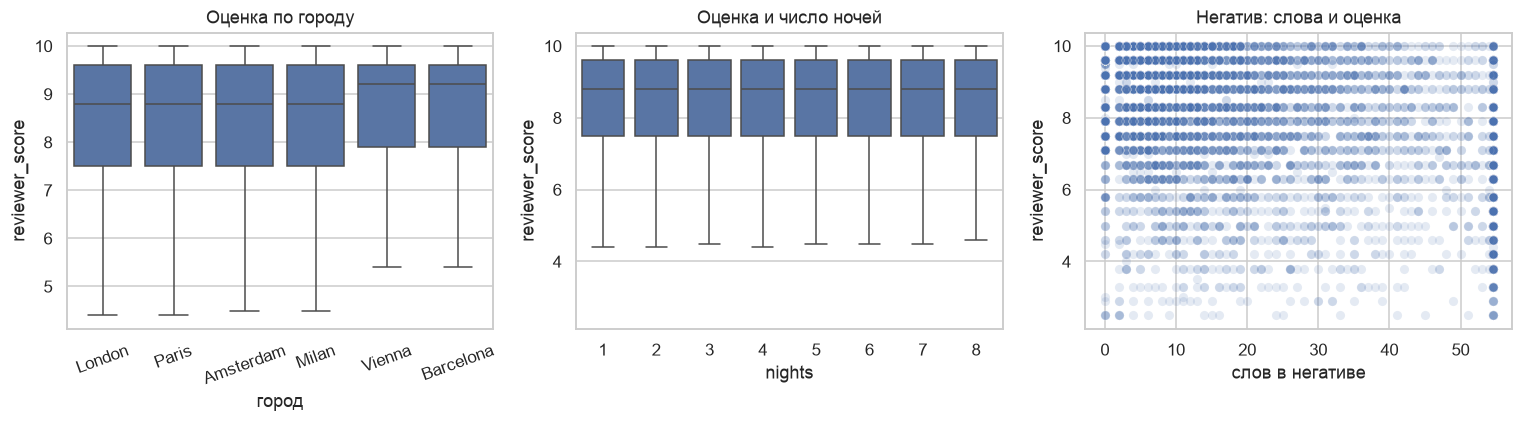

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(
    data=df, x="city", y="reviewer_score", showfliers=False, ax=axes[0]
)
axes[0].set_title("Оценка по городу")
axes[0].set_xlabel("город")
axes[0].set_ylabel("reviewer_score")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=df, x="nights", y="reviewer_score", showfliers=False, ax=axes[1]
)
axes[1].set_xlim(-0.5, 7.5)
axes[1].set_title("Оценка и число ночей")
axes[1].set_xlabel("nights")
axes[1].set_ylabel("reviewer_score")

sample = df.sample(8000, random_state=42)
sns.scatterplot(
    data=sample,
    x="review_total_negative_word_counts",
    y="reviewer_score",
    alpha=0.15,
    ax=axes[2],
)
axes[2].set_title("Негатив: слова и оценка")
axes[2].set_xlabel("слов в негативе")
axes[2].set_ylabel("reviewer_score")
plt.tight_layout()
plt.show()

print(
    "медиана leisure:",
    round(df.loc[df["leisure"] == 1, "reviewer_score"].median(), 2),
)
print(
    "медиана business:",
    round(df.loc[df["business"] == 1, "reviewer_score"].median(), 2),
)


Лондон чуть злее остальных, но медианы близкие. Бизнес ставит ниже, чем leisure. Чем длиннее негатив, тем ниже оценка - это уже похоже на рабочий признак, не на шум


## 4. Пропуски координат

Нулями широту не забиваю: это океан. Беру медиану того же отеля, если нет - медиану города. `dist_center` - квадрат отклонения от этой медианы, без геокодеров


In [23]:
hotel_lat = df.groupby("hotel_name")["lat"].median()
hotel_lng = df.groupby("hotel_name")["lng"].median()
city_lat = df.groupby("city")["lat"].median()
city_lng = df.groupby("city")["lng"].median()
lat_med = df["lat"].median()
lng_med = df["lng"].median()


def fill_coords(frame):
    out = frame.copy()
    out["lat"] = out["lat"].fillna(out["hotel_name"].map(hotel_lat))
    out["lng"] = out["lng"].fillna(out["hotel_name"].map(hotel_lng))
    out["lat"] = out["lat"].fillna(out["city"].map(city_lat)).fillna(lat_med)
    out["lng"] = out["lng"].fillna(out["city"].map(city_lng)).fillna(lng_med)
    out["dist_center"] = (
        (out["lat"] - out["city"].map(city_lat)) ** 2
        + (out["lng"] - out["city"].map(city_lng)) ** 2
    )
    return out


df = fill_coords(df)
print("пропусков lat/lng:", int(df["lat"].isna().sum()), int(df["lng"].isna().sum()))


пропусков lat/lng: 0 0


## 5. Внешние таблицы из EDA-3

Как в задаче про вино: `country_population.csv` и `country_area.csv`. В файле курса China встречается дважды, перед join убираю дубли. US в таблице подписан как `US`, у гостей - United States of America, это один ключ


In [25]:
pop = pd.read_csv("data/country_population.csv", sep=";")
pop = pop.drop_duplicates(subset=["country"], keep="first")
pop["population"] = (
    pop["population"].astype(str).str.replace(",", "", regex=False).astype(float)
)
area = pd.read_csv("data/country_area.csv", sep=";")
area = area.drop_duplicates(subset=["country"], keep="first")
area["area"] = area["area"].astype(float)
pop_med = pop["population"].median()
area_med = area["area"].median()


def join_ext(frame):
    out = frame.merge(
        pop, left_on="nat_for_pop", right_on="country", how="left"
    )
    out = out.drop(columns=["country"])
    out = out.merge(
        area, left_on="nat_for_pop", right_on="country", how="left"
    )
    out = out.drop(columns=["country", "nat_for_pop"])
    out["population"] = out["population"].fillna(pop_med)
    out["area"] = out["area"].fillna(area_med)
    out["population_log"] = np.log1p(out["population"])
    return out


df = join_ext(df)
print(df.shape)
print("без населения:", int(df["population"].isna().sum()))


(386496, 74)
без населения: 0


## 6. Кодирование, отбор, шкалирование

Город и страна отеля - `OneHotEncoder` из `category_encoders`. Национальность и имя отеля - `BinaryEncoder`: кардинальность большая, one-hot раздует таблицу. Так делали в EDA-3


cell_26:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
corr additional vs total reviews: 0.824


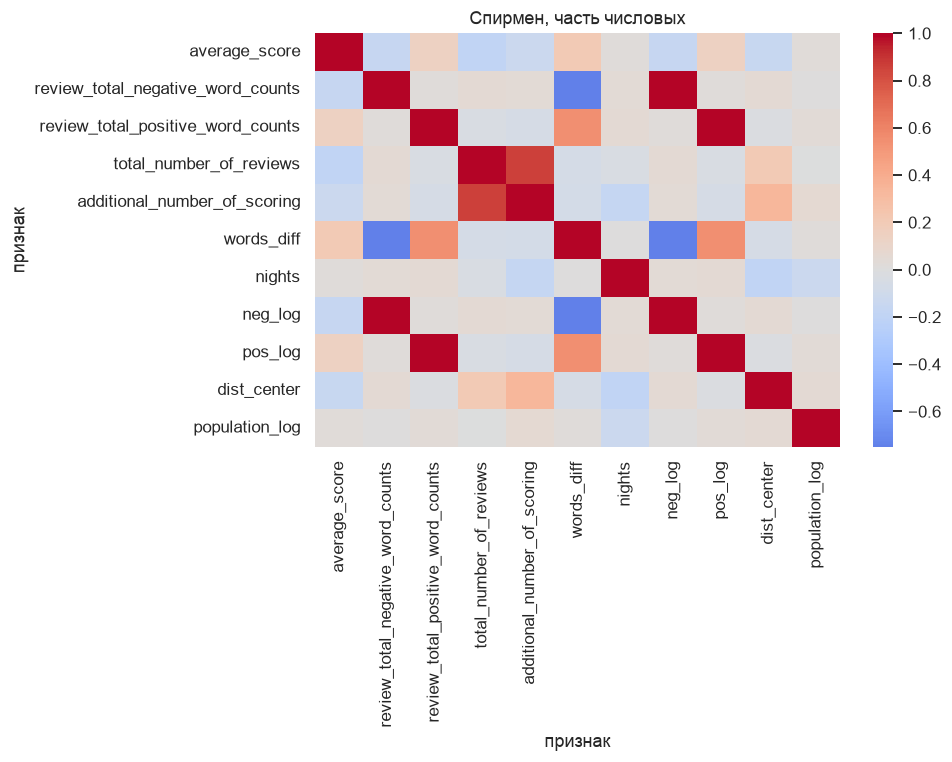

In [27]:
drop_cols = [
    "hotel_address",
    "review_date",
    "reviewer_score",
    "tags",
    "days_since_review",
    "negative_review",
    "positive_review",
    "additional_number_of_scoring",
]
y = df["reviewer_score"]
# city и hotel_country - одна и та же шестёрка, оставляю город
X_raw = df.drop(columns=drop_cols + ["hotel_country"])

num_for_corr = df[
    [
        "average_score",
        "review_total_negative_word_counts",
        "review_total_positive_word_counts",
        "total_number_of_reviews",
        "additional_number_of_scoring",
        "words_diff",
        "nights",
        "neg_log",
        "pos_log",
        "dist_center",
        "population_log",
    ]
].copy()
corr = num_for_corr.corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Спирмен, часть числовых")
ax.set_xlabel("признак")
ax.set_ylabel("признак")
plt.tight_layout()
plt.show()
print(
    "corr additional vs total reviews:",
    round(
        df["additional_number_of_scoring"].corr(df["total_number_of_reviews"]),
        3,
    ),
)


`additional_number_of_scoring` почти дублирует `total_number_of_reviews`. Страну отеля рядом с городом тоже не держу: Лондон всегда UK, Париж всегда Франция


признаков после кодирования: 87
cell_28:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_28:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


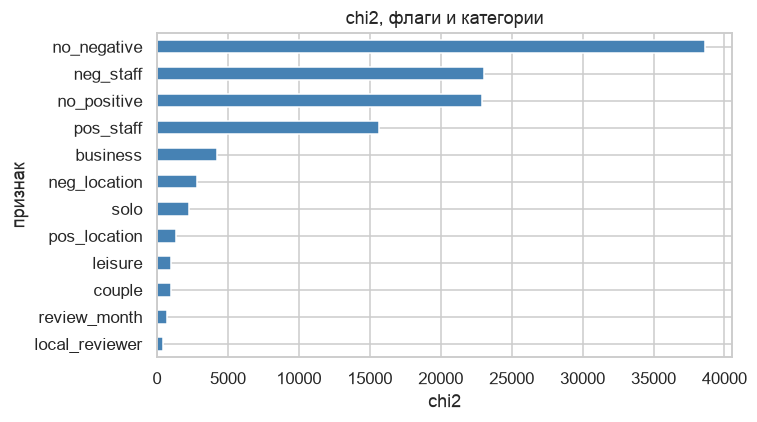

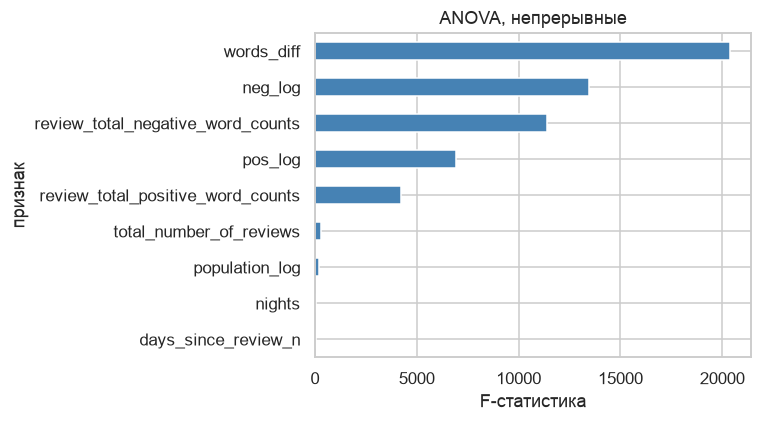

In [29]:
ohe = ce.OneHotEncoder(cols=["city"], use_cat_names=True)
bin_enc = ce.BinaryEncoder(cols=["reviewer_nationality", "hotel_name"])
X = ohe.fit_transform(X_raw)
X = bin_enc.fit_transform(X)
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
print("признаков после кодирования:", X.shape[1])

y_int = y.astype("int")
cat_cols = [
    "leisure",
    "business",
    "couple",
    "solo",
    "review_month",
    "no_negative",
    "no_positive",
    "local_reviewer",
    "neg_staff",
    "pos_staff",
    "neg_location",
    "pos_location",
]
num_cols = [
    "review_total_negative_word_counts",
    "review_total_positive_word_counts",
    "total_number_of_reviews",
    "days_since_review_n",
    "nights",
    "neg_log",
    "pos_log",
    "words_diff",
    "population_log",
]

imp_cat = pd.Series(chi2(X[cat_cols], y_int)[0], index=cat_cols)
imp_cat.sort_values(inplace=True)
fig, ax = plt.subplots(figsize=(7, 4))
imp_cat.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("chi2, флаги и категории")
ax.set_xlabel("chi2")
ax.set_ylabel("признак")
plt.tight_layout()
plt.show()

imp_num = pd.Series(f_classif(X[num_cols], y_int)[0], index=num_cols)
imp_num.sort_values(inplace=True)
fig, ax = plt.subplots(figsize=(7, 4))
imp_num.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("ANOVA, непрерывные")
ax.set_xlabel("F-статистика")
ax.set_ylabel("признак")
plt.tight_layout()
plt.show()


По chi2 сильнее шаблоны отзыва и флаги staff/location. По ANOVA - число слов в негативе и `words_diff`. Дальше SelectKBest забирает 50 лучших по ANOVA, как в подсказке юнита 4. Долготу в chi2 не клал: там минусы


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
y_int_train = y_train.astype("int")
selector = SelectKBest(f_classif, k=50)
X_train = pd.DataFrame(
    selector.fit_transform(X_train, y_int_train),
    columns=X.columns[selector.get_support()],
    index=X_train.index,
)
X_test = pd.DataFrame(
    selector.transform(X_test),
    columns=X_train.columns,
    index=X_test.index,
)
print("отобрал признаков:", X_train.shape[1])
print("снял:", ", ".join(X.columns[~selector.get_support()][:12]), "...")

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

regr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regr.fit(X_train_s, y_train)
y_pred = regr.predict(X_test_s)
print("MAPE:", metrics.mean_absolute_percentage_error(y_test, y_pred))


отобрал признаков: 50
снял: hotel_name_0, hotel_name_1, hotel_name_2, hotel_name_3, hotel_name_4, hotel_name_5, hotel_name_6, hotel_name_7, hotel_name_8, hotel_name_9, hotel_name_10, reviewer_nationality_0 ...
MAPE: 0.12599454851832326


MAPE **0.126** против 0.141 на грубой базе. Лес тот же, из шаблона. Дубли снял, хвосты по словам клипнул, SelectKBest оставил 50 признаков. RobustScaler оставил: после клипа выбросы всё ещё не ноль


## 7. Kaggle

Соревнование: https://www.kaggle.com/competitions/sf-booking

1. **Rules** - принять, иначе Data не откроется
2. Файлы уже в `data/sf-booking/`
3. Ячейка ниже пишет `data/submission_predict.csv`
4. **Submit Predictions** - загрузить csv
5. Ментору: ссылка на GitHub и ник на Kaggle

Тестовый файл без `reviewer_score` и без `id`. Порядок строк совпадает с образцом сабмита, в `id` подставлять ничего не нужно


In [34]:
def clip_word_counts(frame):
    out = frame.copy()
    out["review_total_negative_word_counts"] = (
        out["review_total_negative_word_counts"].clip(upper=neg_hi)
    )
    out["review_total_positive_word_counts"] = (
        out["review_total_positive_word_counts"].clip(upper=pos_hi)
    )
    return out


test_path = DATA_DIR / "hotels_test.csv"
sample_path = DATA_DIR / "submission.csv"
if not test_path.exists() or not sample_path.exists():
    print("положи hotels_test.csv и submission.csv в data/sf-booking/")
else:
    hotels_test = pd.read_csv(test_path)
    hotels_test = clip_word_counts(hotels_test)
    sample = pd.read_csv(sample_path)
    test_f = add_raw_features(hotels_test)
    test_f = fill_coords(test_f)
    test_f = join_ext(test_f)
    X_te_raw = test_f.drop(
        columns=[col for col in drop_cols + ["hotel_country"] if col in test_f.columns]
    )
    X_te = ohe.transform(X_te_raw)
    X_te = bin_enc.transform(X_te)
    X_te = X_te.apply(pd.to_numeric, errors="coerce").fillna(0)
    X, X_te = X.align(X_te, join="left", axis=1, fill_value=0)

    X_sel = pd.DataFrame(
        selector.fit_transform(X, y.astype("int")),
        columns=X.columns[selector.get_support()],
        index=X.index,
    )
    X_te_sel = pd.DataFrame(
        selector.transform(X_te),
        columns=X_sel.columns,
        index=X_te.index,
    )

    scaler_full = RobustScaler()
    X_full_s = scaler_full.fit_transform(X_sel)
    X_te_s = scaler_full.transform(X_te_sel)
    model = RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    )
    model.fit(X_full_s, y)
    pred_test = np.clip(model.predict(X_te_s), 1, 10)

    submit = sample.copy()
    submit["reviewer_score"] = pred_test
    out_path = Path("data/submission_predict.csv")
    submit.to_csv(out_path, index=False)
    print("записал", out_path, submit.shape)
    print(submit.head())


записал data/submission_predict.csv (128935, 2)
   reviewer_score      id
0           8.777  488440
1           7.457  274649
2           8.543  374688
3           9.834  404352
4           9.461  451596


## Итоги

Сырой файл лесу не отдать: адрес, теги и дата - строки, в координатах дырки, плюс полные дубли. Грубая база дала MAPE 0.141. Снял дубли, клипнул хвосты по словам, достал город и теги, подтянул население страны гостя, закодировал отель BinaryEncoder и отсёк лишнее SelectKBest. Ошибка стала 0.126. `additional_number_of_scoring` выкинул из-за корреляции с числом отзывов
